Dans ce fichier nous utilisons des techniques d'apprentissages non supervisées. Ces techniques sont utiles lorsque les datasets ne comportent pas beaucoup d'instances labélisées. Nous reprenons le critère défini dans le notebook 2 (compris résitance/ductilité). Comme nous sommes dans un cadre de régréssion, nous allons nous intéresser à la méthode du pseudo-étiquetage (Pseudo-labeling). 

# 09 — Régression semi-supervisée

## Objectif

Les notebooks précédents donnent :

- une **cible continue** `score_compromis`, comprise entre 0 et 1 ;
- des entrées `X` constituées de composition chimique + paramètres de soudage ;
- des variables numériques et catégorielles ;
- des valeurs manquantes dans `X` ;
- une séparation **développement / test par groupe**, avec le test conservé pour l'évaluation finale.

L'objectif ici est de simuler une situation semi-supervisée : seules une partie des lignes du développement possède une cible `y`, tandis que les autres lignes sont disponibles avec leur `X` mais sans `y`.

### Méthode retenue : Laplacian Regularized Regression

On utilise une régression ridge enrichie par une régularisation de graphe :

$$
\min_\beta
\|X_L\beta-y_L\|^2
+\alpha\|\beta\|^2
+\gamma\,(X\beta)^T L(X\beta),
$$

où :

- $L$ est le Laplacien d'un graphe construit à partir des **données labellisées et non labellisées** ;
- $\alpha$ contrôle la régularisation classique ;
- $\gamma$ impose que des observations proches dans l'espace des entrées aient des prédictions proches.

Cette approche exploite donc réellement les données non labellisées, contrairement à une régression supervisée classique.

Le test reste complètement séparé et n'est jamais utilisé pour construire le graphe ou ajuster les paramètres.


In [2]:
import sys
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import NearestNeighbors
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.stats import spearmanr

SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed" / "dataset_traction.csv"
META = ROOT / "data" / "processed" / "welddb_metadata.json"

if not DATA.exists():
    raise FileNotFoundError(
        f"{DATA} introuvable. Exécute d'abord les notebooks 01–03 "
        "dans la racine du projet, puis relance celui-ci."
    )

print("Racine du projet :", ROOT)
print("Dataset :", DATA)


Racine du projet : c:\Users\pascu\Documents\Aero 5 - CentraleSupelec - IA\Cours\Apprentissage Automatique (ML)\Projet\projet-soudures
Dataset : c:\Users\pascu\Documents\Aero 5 - CentraleSupelec - IA\Cours\Apprentissage Automatique (ML)\Projet\projet-soudures\data\processed\dataset_traction.csv


## 1. Charger les données

On reprend exactement la partition créée dans le notebook 02. `WeldID`, `groupe` et `partition` ne sont pas des variables d'entrée.

Pour la préparation, on repart de `X` brut afin que les médianes, catégories et paramètres de standardisation soient appris uniquement sur les données considérées comme d'apprentissage.


In [3]:
categories = ["AC_DC", "Electrode_pol", "WeldType"]

donnees = pd.read_csv(
    DATA,
    index_col="row_id",
    dtype={c: str for c in categories + ["WeldID", "partition"]},
    keep_default_na=False,
    na_values=[""],
    float_precision="round_trip"
)

if META.exists():
    schema = json.loads(META.read_text())["schema"]
    variables_X = schema["COMPOSITION"] + schema["PROCESS"]
else:
    variables_X = [
        c for c in donnees.columns
        if c not in ["WeldID", "groupe", "partition",
                     "UTS_MPa", "Elongation_pct", "score_compromis"]
    ]

X = donnees[variables_X].copy()
y = donnees["score_compromis"].copy()
groupes = donnees["groupe"].copy()

developpement = donnees["partition"].eq("developpement")
test = donnees["partition"].eq("test")

X_dev = X.loc[developpement].copy()
y_dev = y.loc[developpement].copy()
groupes_dev = groupes.loc[developpement].copy()

X_test = X.loc[test].copy()
y_test = y.loc[test].copy()

print(f"Développement : {len(X_dev)} lignes")
print(f"Test : {len(X_test)} lignes")
print(f"Variables brutes : {len(variables_X)}")
print(f"Groupes développement : {groupes_dev.nunique()}")


Développement : 539 lignes
Test : 127 lignes
Variables brutes : 30
Groupes développement : 384


## 2. Préparation des variables

On conserve le principe du notebook 03 :

- colonnes numériques : médiane ;
- colonnes catégorielles : catégorie `manquant` puis one-hot ;
- standardisation des variables numériques.

La préparation est ajustée sur le **sous-ensemble labellisé**. Les données non labellisées servent ensuite à construire le graphe, mais elles ne déterminent pas les médianes ni les catégories apprises.

Le seuil de 25 % de valeurs disponibles est également calculé sur les données labellisées.


In [4]:
def construire_preparation(X_labeled, seuil=0.25):
    remplissage = X_labeled.notna().mean()
    colonnes = remplissage[remplissage >= seuil].index.tolist()

    X0 = X_labeled[colonnes].copy()

    cols_cat = [c for c in categories if c in X0.columns]
    cols_num = [c for c in X0.columns if c not in cols_cat]

    transform_num = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    transform_cat = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="manquant")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ])

    preparation = ColumnTransformer(
        transformers=[
            ("num", transform_num, cols_num),
            ("cat", transform_cat, cols_cat)
        ],
        remainder="drop"
    )
    return preparation, colonnes


def appliquer_preparation(X_labeled, X_unlabeled, X_test, seuil=0.25):
    preparation, colonnes = construire_preparation(X_labeled, seuil)
    preparation.fit(X_labeled[colonnes])

    A_l = preparation.transform(X_labeled[colonnes])
    A_u = preparation.transform(X_unlabeled[colonnes])
    A_t = preparation.transform(X_test[colonnes])

    A_l = A_l.toarray() if sparse.issparse(A_l) else np.asarray(A_l)
    A_u = A_u.toarray() if sparse.issparse(A_u) else np.asarray(A_u)
    A_t = A_t.toarray() if sparse.issparse(A_t) else np.asarray(A_t)

    return A_l, A_u, A_t, preparation, colonnes


print("Fonctions de préparation définies.")


Fonctions de préparation définies.


## 3. Régression semi-supervisée par graphe

Le graphe est construit avec les observations labellisées **et** non labellisées.

Pour chaque observation, on relie ses `k` plus proches voisins avec un poids RBF :

$$
w_{ij}=\exp\left(-\frac{\|x_i-x_j\|^2}{2\sigma^2}\right).
$$

Puis :

$$
L=D-W.
$$

La solution utilisée est :

$$
\hat\beta =
\left(
X_L^T X_L
+ \alpha I
+ \gamma X^T L X
\right)^{-1}
X_L^T y_L.
$$

C'est une version inductive : après apprentissage, `predict()` fonctionne sur de nouvelles observations du test.


In [5]:
class LaplacianRidge(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1e-2, gamma=1.0, n_neighbors=10,
                 rbf_scale=None, include_intercept=True):
        self.alpha = alpha
        self.gamma = gamma
        self.n_neighbors = n_neighbors
        self.rbf_scale = rbf_scale
        self.include_intercept = include_intercept

    def _graphe(self, X):
        n = len(X)
        k = min(self.n_neighbors, n - 1)

        nn = NearestNeighbors(n_neighbors=k + 1)
        nn.fit(X)
        distances, indices = nn.kneighbors(X)

        distances = distances[:, 1:]
        indices = indices[:, 1:]

        if self.rbf_scale is None:
            sigma = np.median(distances[distances > 0])
            if not np.isfinite(sigma) or sigma <= 0:
                sigma = 1.0
        else:
            sigma = self.rbf_scale

        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        weights = np.exp(-(distances.ravel() ** 2) / (2 * sigma ** 2))

        W = sparse.coo_matrix(
            (weights, (rows, cols)),
            shape=(n, n)
        ).tocsr()

        # Graphe symétrique : deux points sont proches si l'un est
        # dans le voisinage de l'autre.
        W = 0.5 * (W + W.T)
        D = sparse.diags(np.asarray(W.sum(axis=1)).ravel())
        return D - W

    def fit(self, X_labeled, y_labeled, X_unlabeled=None):
        X_labeled = np.asarray(X_labeled, dtype=float)
        y_labeled = np.asarray(y_labeled, dtype=float).ravel()

        if X_unlabeled is None or len(X_unlabeled) == 0:
            X_unlabeled = np.empty((0, X_labeled.shape[1]))

        X_unlabeled = np.asarray(X_unlabeled, dtype=float)
        X_all = np.vstack([X_labeled, X_unlabeled])

        self.n_features_in_ = X_labeled.shape[1]
        self.L_ = self._graphe(X_all)

        if self.include_intercept:
            Xl = np.column_stack([np.ones(len(X_labeled)), X_labeled])
            Xa = np.column_stack([np.ones(len(X_all)), X_all])
            I = np.eye(Xl.shape[1])
            I[0, 0] = 0.0
        else:
            Xl = X_labeled
            Xa = X_all
            I = np.eye(Xl.shape[1])

        A = Xl.T @ Xl + self.alpha * I

        LX = self.L_ @ Xa
        A = A + self.gamma * (Xa.T @ LX)

        b = Xl.T @ y_labeled

        self.coef_ = np.linalg.solve(A + 1e-10 * np.eye(A.shape[0]), b)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        if self.include_intercept:
            X = np.column_stack([np.ones(len(X)), X])
        return X @ self.coef_


## 4. Fonctions d'évaluation

Le score cible est borné entre 0 et 1. On regarde :

- **MAE** : erreur absolue moyenne ;
- **RMSE** : pénalise davantage les grosses erreurs ;
- **R²** : part de variance expliquée ;
- **Spearman** : intéressant ici car le score sert aussi à classer les soudures.

Le test ne sera utilisé qu'une fois pour l'évaluation finale.


In [6]:
def metriques(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
        "Spearman": spearmanr(y_true, y_pred).statistic
    }


def afficher_resultats(y_true, y_pred, titre):
    resultats = metriques(y_true, y_pred)
    print(titre)
    for nom, valeur in resultats.items():
        print(f"  {nom:10s}: {valeur:.4f}")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, alpha=0.7)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("Score réel")
    ax.set_ylabel("Score prédit")
    ax.set_title(titre)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.tight_layout()
    plt.show()

    return resultats


## 5. Première expérience : 50 % de labels

On sélectionne environ la moitié des **groupes** du développement comme données labellisées.

L'autre moitié reste totalement non labellisée pour l'algorithme : ses valeurs de `y` ne sont pas utilisées. Elles servent uniquement à vérifier, après coup, que le principe semi-supervisé fonctionne.

Pour une comparaison honnête, le modèle supervisé de référence reçoit exactement les mêmes observations labellisées.


Labellisé : 274 lignes, 192 groupes
Non labellisé : 265 lignes, 192 groupes
Groupes disjoints : True
LapRLS — 50 % des groupes labellisés
  MAE       : 0.1016
  RMSE      : 0.1338
  R2        : 0.0705
  Spearman  : 0.4669


c:\Users\pascu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\pascu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


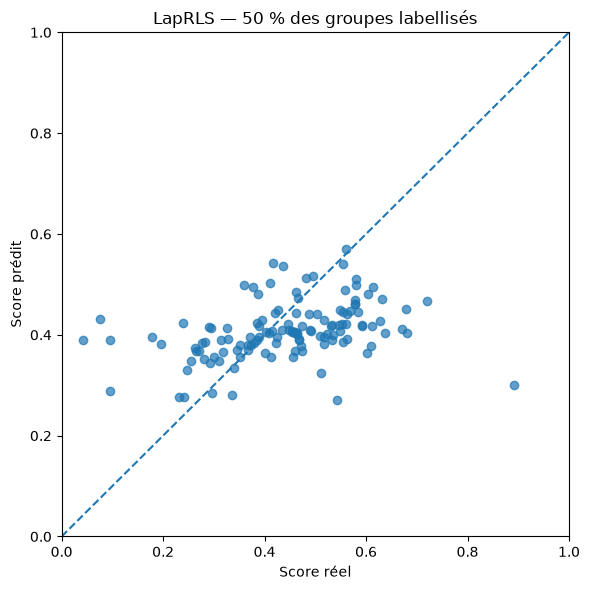

In [7]:
def split_labellise_non_labellise(X, y, groupes, fraction=0.5, seed=42):
    splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=fraction,
        random_state=seed
    )
    idx_l, idx_u = next(splitter.split(X, y, groups=groupes))

    return (
        X.iloc[idx_l], y.iloc[idx_l], groupes.iloc[idx_l],
        X.iloc[idx_u], y.iloc[idx_u], groupes.iloc[idx_u]
    )


X_l, y_l, g_l, X_u, y_u, g_u = split_labellise_non_labellise(
    X_dev, y_dev, groupes_dev, fraction=0.5, seed=SEED
)

print(f"Labellisé : {len(X_l)} lignes, {g_l.nunique()} groupes")
print(f"Non labellisé : {len(X_u)} lignes, {g_u.nunique()} groupes")
print("Groupes disjoints :", set(g_l).isdisjoint(set(g_u)))

A_l, A_u, A_test, preparation, colonnes = appliquer_preparation(
    X_l, X_u, X_test
)

modele_ssl = LaplacianRidge(
    alpha=1e-2,
    gamma=1.0,
    n_neighbors=10
)
modele_ssl.fit(A_l, y_l, A_u)

pred_ssl = np.clip(modele_ssl.predict(A_test), 0, 1)
resultat_ssl = afficher_resultats(
    y_test, pred_ssl,
    "LapRLS — 50 % des groupes labellisés"
)


Ridge supervisée — 50 % des groupes labellisés
  MAE       : 0.0962
  RMSE      : 0.1266
  R2        : 0.1689
  Spearman  : 0.5289


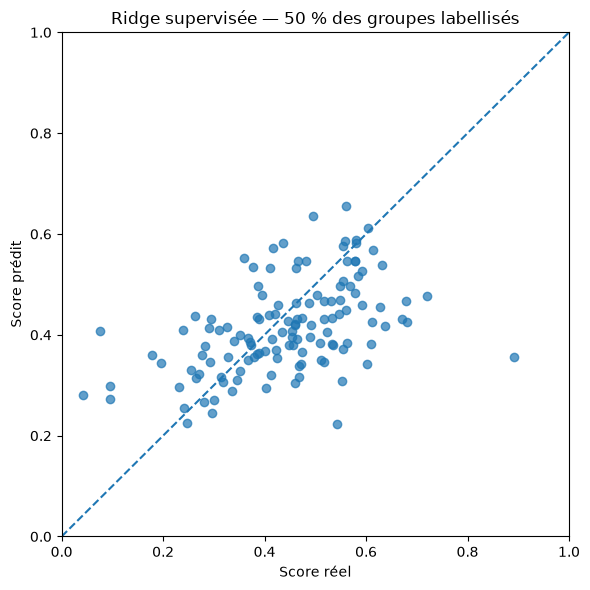

,MAE,RMSE,R2,Spearman
Ridge supervisée,0.0962,0.1266,0.1689,0.5289
LapRLS semi-supervisée,0.1016,0.1338,0.0705,0.4669


In [8]:
# Référence supervisée : Ridge avec exactement les mêmes labels.
modele_ridge = Ridge(alpha=1.0)
modele_ridge.fit(A_l, y_l)
pred_ridge = np.clip(modele_ridge.predict(A_test), 0, 1)

resultat_ridge = afficher_resultats(
    y_test, pred_ridge,
    "Ridge supervisée — 50 % des groupes labellisés"
)

comparaison = pd.DataFrame(
    [resultat_ridge, resultat_ssl],
    index=["Ridge supervisée", "LapRLS semi-supervisée"]
)
display(comparaison.round(4))


## 6. Étudier l'intérêt du semi-supervisé

Une vraie façon de juger l'intérêt de l'approche est de faire varier la quantité de données labellisées.

Pour chaque fraction, on compare :

1. une Ridge qui n'utilise que les labels disponibles ;
2. LapRLS, qui utilise ces mêmes labels **+ les `X` non labellisés**.

Les résultats sont moyennés sur plusieurs tirages par groupe afin de ne pas dépendre d'un seul découpage.


In [9]:
fractions = [0.10, 0.20, 0.40, 0.60, 0.80]
seeds = [42, 43, 44, 45, 46]

resultats_fraction = []

for fraction in fractions:
    for seed in seeds:
        X_l, y_l, g_l, X_u, y_u, g_u = split_labellise_non_labellise(
            X_dev, y_dev, groupes_dev,
            fraction=fraction,
            seed=seed
        )

        A_l, A_u, A_test, _, _ = appliquer_preparation(X_l, X_u, X_test)

        ridge = Ridge(alpha=1.0)
        ridge.fit(A_l, y_l)
        pred_ridge = np.clip(ridge.predict(A_test), 0, 1)
        m_ridge = metriques(y_test, pred_ridge)

        ssl = LaplacianRidge(
            alpha=1e-2,
            gamma=1.0,
            n_neighbors=10
        )
        ssl.fit(A_l, y_l, A_u)
        pred_ssl = np.clip(ssl.predict(A_test), 0, 1)
        m_ssl = metriques(y_test, pred_ssl)

        resultats_fraction.append({
            "fraction_labels": fraction,
            "seed": seed,
            "modele": "Ridge supervisée",
            **m_ridge
        })
        resultats_fraction.append({
            "fraction_labels": fraction,
            "seed": seed,
            "modele": "LapRLS semi-supervisée",
            **m_ssl
        })

resultats_fraction = pd.DataFrame(resultats_fraction)

resume = (
    resultats_fraction
    .groupby(["fraction_labels", "modele"])
    .agg(
        MAE_moy=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_moy=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_moy=("R2", "mean"),
        R2_std=("R2", "std"),
        Spearman_moy=("Spearman", "mean"),
        Spearman_std=("Spearman", "std")
    )
    .reset_index()
)

display(resume.round(4))


c:\Users\pascu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\pascu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\pascu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\pascu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1, 2] 

,fraction_labels,modele,MAE_moy,MAE_std,RMSE_moy,RMSE_std,R2_moy,R2_std,Spearman_moy,Spearman_std
0,0.1,LapRLS semi-supervisée,0.1240,0.0046,0.1573,0.0060,-0.2853,0.1001,0.1458,0.1088
1,0.1,Ridge supervisée,0.1494,0.0303,0.1981,0.0394,-1.1001,0.8259,0.3259,0.1584
2,0.2,LapRLS semi-supervisée,0.1137,0.0030,0.1453,0.0034,-0.0963,0.0506,0.2849,0.1021
3,0.2,Ridge supervisée,0.1117,0.0047,0.1470,0.0100,-0.1252,0.1566,0.4814,0.0521
4,0.4,LapRLS semi-supervisée,0.1059,0.0018,0.1373,0.0024,0.0214,0.0338,0.4421,0.0506
5,0.4,Ridge supervisée,0.0964,0.0028,0.1273,0.0026,0.1595,0.0337,0.5653,0.0407
6,0.6,LapRLS semi-supervisée,0.1011,0.0012,0.1314,0.0022,0.1044,0.0300,0.5017,0.0387
7,0.6,Ridge supervisée,0.0924,0.0013,0.1229,0.0037,0.2159,0.0477,0.6034,0.0382
8,0.8,LapRLS semi-supervisée,0.0993,0.0019,0.1307,0.0055,0.1121,0.0765,0.5295,0.0317
9,0.8,Ridge supervisée,0.0906,0.0017,0.1191,0.0049,0.2626,0.0624,0.6211,0.0110


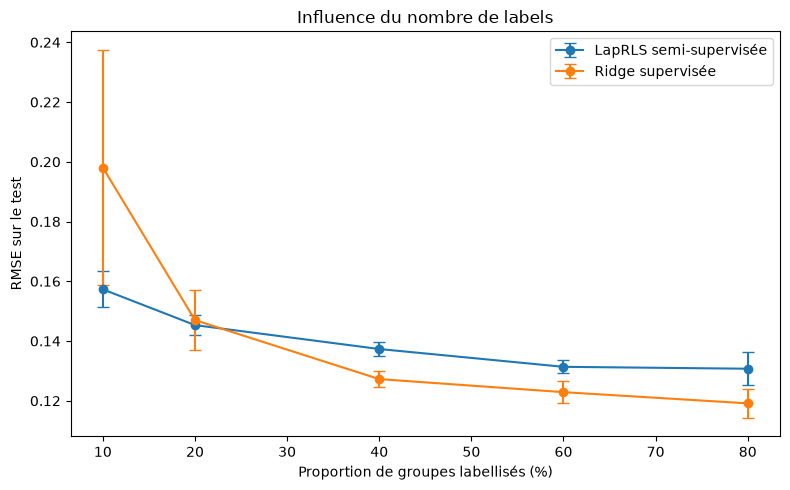

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for modele in resume["modele"].unique():
    sous = resume[resume["modele"] == modele]
    ax.errorbar(
        sous["fraction_labels"] * 100,
        sous["RMSE_moy"],
        yerr=sous["RMSE_std"],
        marker="o",
        capsize=4,
        label=modele
    )

ax.set_xlabel("Proportion de groupes labellisés (%)")
ax.set_ylabel("RMSE sur le test")
ax.set_title("Influence du nombre de labels")
ax.legend()
fig.tight_layout()
plt.show()


## 7. Sensibilité aux hyperparamètres

Les deux paramètres principaux sont :

- `alpha` : régularisation ridge ;
- `gamma` : poids de la régularisation de graphe.

`gamma = 0` revient à une Ridge classique dans cette formulation. Une valeur positive permet d'exploiter la structure des observations non labellisées.

La recherche ci-dessous est volontairement légère. Pour un rapport, on peut ensuite faire une validation croisée par groupes plus complète.


In [11]:
# Recherche simple sur un découpage 50/50 fixe.
X_l, y_l, g_l, X_u, y_u, g_u = split_labellise_non_labellise(
    X_dev, y_dev, groupes_dev, fraction=0.5, seed=SEED
)
A_l, A_u, A_test, _, _ = appliquer_preparation(X_l, X_u, X_test)

grille = [
    (1e-3, 0.0),
    (1e-2, 0.0),
    (1e-1, 0.0),
    (1e-3, 0.1),
    (1e-2, 0.1),
    (1e-1, 0.1),
    (1e-3, 1.0),
    (1e-2, 1.0),
    (1e-1, 1.0),
    (1e-3, 10.0),
    (1e-2, 10.0),
    (1e-1, 10.0),
]

table_hyper = []

for alpha, gamma in grille:
    modele = LaplacianRidge(
        alpha=alpha,
        gamma=gamma,
        n_neighbors=10
    )
    modele.fit(A_l, y_l, A_u)
    pred = np.clip(modele.predict(A_test), 0, 1)

    table_hyper.append({
        "alpha": alpha,
        "gamma": gamma,
        **metriques(y_test, pred)
    })

table_hyper = pd.DataFrame(table_hyper).sort_values("RMSE")
display(table_hyper.round(4))


c:\Users\pascu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\pascu\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,alpha,gamma,MAE,RMSE,R2,Spearman
2,0.100,0.0,0.0979,0.1284,0.1446,0.5272
5,0.100,0.1,0.0970,0.1285,0.1438,0.5173
4,0.010,0.1,0.0970,0.1285,0.1438,0.5149
3,0.001,0.1,0.0970,0.1285,0.1437,0.5151
1,0.010,0.0,0.0985,0.1294,0.1318,0.5270
0,0.001,0.0,0.0985,0.1295,0.1300,0.5275
8,0.100,1.0,0.1017,0.1338,0.0707,0.4685
7,0.010,1.0,0.1016,0.1338,0.0705,0.4669
6,0.001,1.0,0.1016,0.1338,0.0705,0.4671
11,0.100,10.0,0.1097,0.1393,-0.0063,0.3756


## 8. Interprétation et conclusion

Le résultat à retenir n'est pas uniquement la meilleure RMSE. Il faut surtout vérifier si **LapRLS apporte un gain par rapport à la Ridge lorsqu'on diminue le nombre de labels**.

### Ce que l'on attend

- Avec beaucoup de labels, la différence entre supervisé et semi-supervisé peut devenir faible.
- Avec peu de labels, LapRLS peut bénéficier de la géométrie des observations non labellisées.
- Si `gamma` optimal est proche de 0, les données non labellisées n'apportent pas d'information exploitable avec ce graphe.
- Une dégradation avec un `gamma` trop grand signifie que l'hypothèse de lissage sur le graphe est trop forte.

### Attention méthodologique

Le test est conservé à part conformément aux notebooks précédents. Les expériences sur les fractions de labels utilisent le test uniquement pour mesurer la performance finale de chaque expérience ; pour sélectionner définitivement `alpha`, `gamma` et `k`, il faudra idéalement faire une **validation croisée par groupes sur le développement**, puis n'évaluer le modèle final qu'une seule fois sur le test.

Enfin, le `score_compromis` est une cible relative construite à partir des rangs UTS/allongement. Les métriques mesurent donc la capacité à prédire **ce score**, pas directement une propriété mécanique absolue.
